# **Lab 01 - Introduction to Python, Gymnasium and Formulating RL Problem**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Getting familiar with Gymnasium

In [1]:
# import Gymnasium library and alias as gym
import gymnasium as gym

In [3]:
total_reward = 0
truncated = False
done = False

In [4]:
# Create the MountainCar-v0 environment and reset to obtain the initial observation
### YOU NEED TO WRITE YOUR CODE BELOW ###
# HERE 
env = gym.make('MountainCar-v0', render_mode='human')
observation, _ = env.reset(seed=2026)


c:\Users\pc\anaconda3\envs\nt549-11-Nguyen\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [5]:
def policy(observation):
    if observation[1] > 0:
        return 2
    else:
        return 0



In [6]:
while not done and not truncated:

    # Define action by sampling randomly from the environment action space
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    action = policy(observation)

    # Execute the action
    # HERE
    new_obs, reward, done, truncated, info = env.step(action)
    
    total_reward += reward
    observation = new_obs
    env.render()

print("Reward: {}".format(total_reward))
env.close()

Reward: -154.0


## Part 2: Custom Environment "VacuumCleaner"

In [2]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.action_space = gym.spaces.Discrete(4)

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position':  gym.spaces.Box(low=np.array([0, 0]), high=np.array([m-1, n-1]), shape=(2,), dtype=np.int32),
            'dust': gym.spaces.Box(low=0, high=1, shape=(m, n), dtype=np.int32)
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = np.array([0, 0], dtype=np.int32)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.random.randint(2, size=(self.m, self.n))

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = self.position + np.array([-1, 0])
        elif action == 1: # Down
            candidate = self.position + np.array([1, 0])
        elif action == 2: # Left
            candidate = self.position + np.array([0, -1])
        elif action == 3: # Right
            candidate = self.position + np.array([0, 1])
        else:
            candidate = self.position.copy()     

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place


        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if self.dust_grid[tuple(self.position)] == 1:
            reward = 1.0
            self.dust_grid[tuple(self.position)] = 0
        else:
            reward = -0.5
        
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [3]:
def robot_policy(option="priority-based", env=None):
     """
     """
     global layer
     current_pos = env.position
     row = int(current_pos[0])
     col = int(current_pos[1])
     if option == "round-robin":
          if (row % 2 == 0):
               if (col < env.n - 1):
                    return 3  # Move right
               else:
                    return 1  # Move down
          else:
               if (col > 0):
                    return 2  # Move left
               else:
                    return 1  # Move down
     elif option == "priority-based":
          if (row == layer + 1) and (col == layer):
               layer += 1
               return 3  # Move right
          if (row == layer) and (col >= layer) and (col < env.n - layer - 1):
               return 3  # Move right
          if (row >= layer) and (row < env.m - layer - 1) and (col == env.n - layer - 1):
               return 1  # Move down
          if (row == env.m - layer - 1) and (col > layer) and (col <= env.n - layer - 1):
               return 2  # Move left
          if (row > layer) and (row <= env.m - layer - 1) and (col == layer):
               return 0  # Move up
          return env.action_space.sample()

In [5]:
layer = 0

if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False
    layer = 0

    while not terminated and not truncated:
        action = robot_policy(option="priority-based", env=env)
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

.    
     
  X  
     
     
Total reward: -0.5
Action: 3, Reward: -10.0, Terminated: True
Episode finished with total reward: -0.5


In [ ]:
def save(*args, **kwargs):
    pass

In [7]:
import numpy as np
import gymnasium as gym

Evaluation and Analysis

## Part 3: Load Balancing Problem

In [8]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.
The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.
Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.
Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is not None:
                  self.remaining_time -= 1
                  if self.remaining_time <= 0:
                        completed_task = self.current_task
                        self.current_task = None
            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None and len(self.queue) > 0:
                  self.current_task = self.queue.popleft()
                  self.remaining_time = self.current_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None:
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True
            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if len(self.queue) < self.queue_capacity:
                  self.queue.append(task)
                  return True

            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [9]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(n_servers)

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(
                         gym.spaces.Dict({
                               "remaining_time": gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=np.float32),
                               "queue_length": gym.spaces.Box(low=0, high=queue_capacity, shape=(), dtype=np.int32),
                         })
                         for _ in range(n_servers)
                  ),
                  "time": gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=np.float32),
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = self.tasks_created[self.next_task_id] = Task(task_id=self.next_task_id, processing_time=self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
                  self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]   
            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created.clear()
            self.tasks_completed.clear()
            self.tasks_dropped.clear()
            self.tasks_accepted.clear()

            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            for server in self.servers:
                  completed_task = server.run_one_step()
                  if completed_task is not None:
                        self.tasks_completed.add(completed_task.task_id)
                        reward += 2.0
            # 2) Generate one new incoming task
            new_task = self._new_task()   

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            selected_server = self.servers[action]
            if selected_server.add_task(new_task):
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * server.queue_length()

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = dropped / total_created if total_created > 0 else 0
            #...

            return {
                  # Some example info fields: time, dropped tasks, dop_rate, etc.
                  "time": self.time,
                  "dropped": dropped,
                  "drop_rate": drop_rate,
                  "completed": completed,
                  "accepted": accepted
            }

In [ ]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      
      if option == "round-robin":
            return env.time % env.n_servers
      if option == "greedy":
            queue_lengths = [server.queue_length() for server in env.servers]
            return int(np.argmin(queue_lengths))
      if option == "epsilon-greedy":
            epsilon = 0.1
            if random.random() < epsilon:
                  return env.action_space.sample()  # Explore
            else:
                  queue_lengths = [server.queue_length() for server in env.servers]
                  return int(np.argmin(queue_lengths))  # Exploit
      raise ValueError(f"Unsupported policy option: {option}")

In [34]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Run fixed number of simulation steps with random policy
      for step in range(100): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="epsilon-greedy", env=env)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            print(f"Step: {step}, Action: {action}, Reward: {reward}, Total Reward: {env.total_reward}")
      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      print("Simulation completed.")
      print(f"Total tasks created: {len(env.tasks_created)}")
      print(f"Total tasks completed: {len(env.tasks_completed)}")
      print(f"Total tasks dropped: {len(env.tasks_dropped)}")
      print(f"Drop rate: {len(env.tasks_dropped) / len(env.tasks_created) if env.tasks_created else 0:.2f}")

Step: 0, Action: 0, Reward: 0.5, Total Reward: 0.5
Step: 1, Action: 0, Reward: 2.5, Total Reward: 3.0
Step: 2, Action: 0, Reward: 2.5, Total Reward: 5.5
Step: 3, Action: 0, Reward: 0.0, Total Reward: 5.5
Step: 4, Action: 1, Reward: 0.0, Total Reward: 5.5
Step: 5, Action: 1, Reward: 2.0, Total Reward: 7.5
Step: 6, Action: 0, Reward: 2.0, Total Reward: 9.5
Step: 7, Action: 1, Reward: 2.0, Total Reward: 11.5
Step: 8, Action: 0, Reward: 4.5, Total Reward: 16.0
Step: 9, Action: 0, Reward: 2.5, Total Reward: 18.5
Step: 10, Action: 0, Reward: 0.0, Total Reward: 18.5
Step: 11, Action: 1, Reward: -0.5, Total Reward: 18.0
Step: 12, Action: 2, Reward: -0.5, Total Reward: 17.5
Step: 13, Action: 2, Reward: 4.0, Total Reward: 21.5
Step: 14, Action: 1, Reward: 6.5, Total Reward: 28.0
Step: 15, Action: 0, Reward: 0.0, Total Reward: 28.0
Step: 16, Action: 1, Reward: 2.0, Total Reward: 30.0
Step: 17, Action: 0, Reward: -0.5, Total Reward: 29.5
Step: 18, Action: 1, Reward: 1.5, Total Reward: 31.0
Step: 1

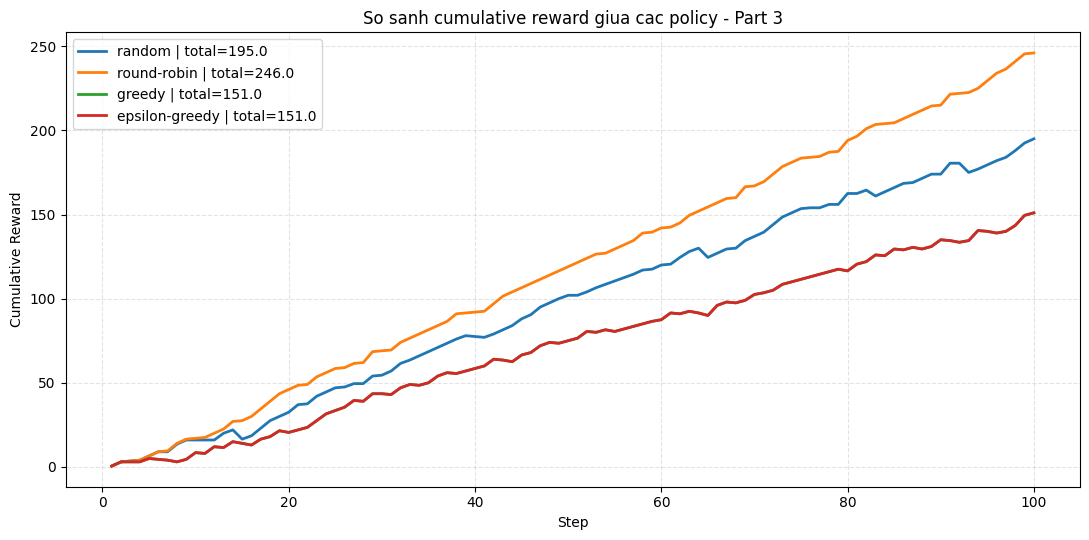

Policy=random         | steps=100 | total=  195.00 | mean=  1.95 | drop_rate=0.00%
Policy=round-robin    | steps=100 | total=  246.00 | mean=  2.46 | drop_rate=0.00%
Policy=greedy         | steps=100 | total=  151.00 | mean=  1.51 | drop_rate=0.00%
Policy=epsilon-greedy | steps=100 | total=  151.00 | mean=  1.51 | drop_rate=0.00%


In [37]:
import random
import numpy as np
import matplotlib.pyplot as plt


def chay_policy_load_balancing(policy_name, n_steps=100, seed=2026, n_servers=10, queue_capacity=1):
    """Chay 1 policy va tra ve reward theo thoi gian."""
    random.seed(seed)
    np.random.seed(seed)

    env = LoadBalancingEnv(n_servers=n_servers, queue_capacity=queue_capacity, seed=seed)
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)

    rewards = []
    for step in range(n_steps):
        action = load_balancing_policy(option=policy_name, env=env)
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(float(reward))
        if terminated or truncated:
            break

    rewards = np.asarray(rewards, dtype=float)
    return {
        "rewards": rewards,
        "cumulative": np.cumsum(rewards),
        "total_reward": float(rewards.sum()) if rewards.size else 0.0,
        "mean_reward": float(rewards.mean()) if rewards.size else 0.0,
        "steps": int(rewards.size),
        "drop_rate": float(info.get("drop_rate", 0.0)),
    }


policies = ["random", "round-robin", "greedy", "epsilon-greedy"]
results = {p: chay_policy_load_balancing(p) for p in policies}

# Ve duong reward tich luy theo step cho tung policy
plt.figure(figsize=(11, 5.5))
for p in policies:
    data = results[p]
    steps = np.arange(1, data["steps"] + 1)
    plt.plot(steps, data["cumulative"], linewidth=2, label=f"{p} | total={data['total_reward']:.1f}")

plt.title("So sanh cumulative reward giua cac policy - Part 3")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# In thong ke nhanh cho tung policy
for p in policies:
    data = results[p]
    print(
        f"Policy={p:14s} | steps={data['steps']:3d} | total={data['total_reward']:8.2f} "
        f"| mean={data['mean_reward']:6.2f} | drop_rate={data['drop_rate']:.2%}"
    )

In [ ]:
def save_metrics(...):
     # Placeholder for a function to save metrics
     pass

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Part 2,3 of Lab01 - Introduction to Python, Gymnasium and Formulating RL Problem.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

Suggested additional practice resources: https://gymnasium.farama.org/introduction/create_custom_env/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
